# Air Quality Variability & City-wise Statistical Comparison

### Data Science Mini Project

**Submitted by:**  


Abhay Kumar 25MCA0130<br>
Shivam Tomar 25MCA0124<br>
Chirag Thathi<br>
Ayush Singh <br>

**Tools Used:**  
Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy  

**Environment:**  
Google Colab

---

## Project Objective

The objective of this project is to analyze Air Quality Index (AQI) data from multiple cities and identify significant patterns and variations using statistical and data science techniques.

The analysis includes:

- Monthly AQI aggregation
- Variability analysis using standard deviation
- Hypothesis testing across cities
- Seasonal trend analysis
- Environmental interpretation of pollution patterns

This study helps understand pollution trends and provides insights into environmental conditions across different cities.

In [1]:
'''Import Required Libraries'''
# ==========================================
# AIR QUALITY VARIABILITY ANALYSIS PROJECT
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats

# Better plot aesthetics
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.1)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
'''Load Dataset'''
df = pd.read_csv("city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
'''Basic Dataset Understanding'''
print(df.shape)
print(df.info())
print(df.describe())

(29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None
              PM2.5          PM10            NO           NO2           NOx  \
coun

In [4]:
'''Data Cleaning & Feature Engineering'''
df.isnull().sum()

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df = df.dropna(subset=['AQI'])

df.fillna(df.mean(numeric_only=True), inplace=True)

print("Clean dataset shape:", df.shape)

Clean dataset shape: (24850, 18)


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step in any data science project.  
It helps us understand the structure, quality, and patterns present in the dataset before applying statistical analysis.

In this section, we will:

- Understand dataset structure
- Identify missing values
- Examine statistical summaries
- Analyze city-wise AQI distribution
- Study pollutant relationships
- Visualize pollution patterns

EDA helps reveal hidden insights and ensures that the dataset is suitable for further analysis.

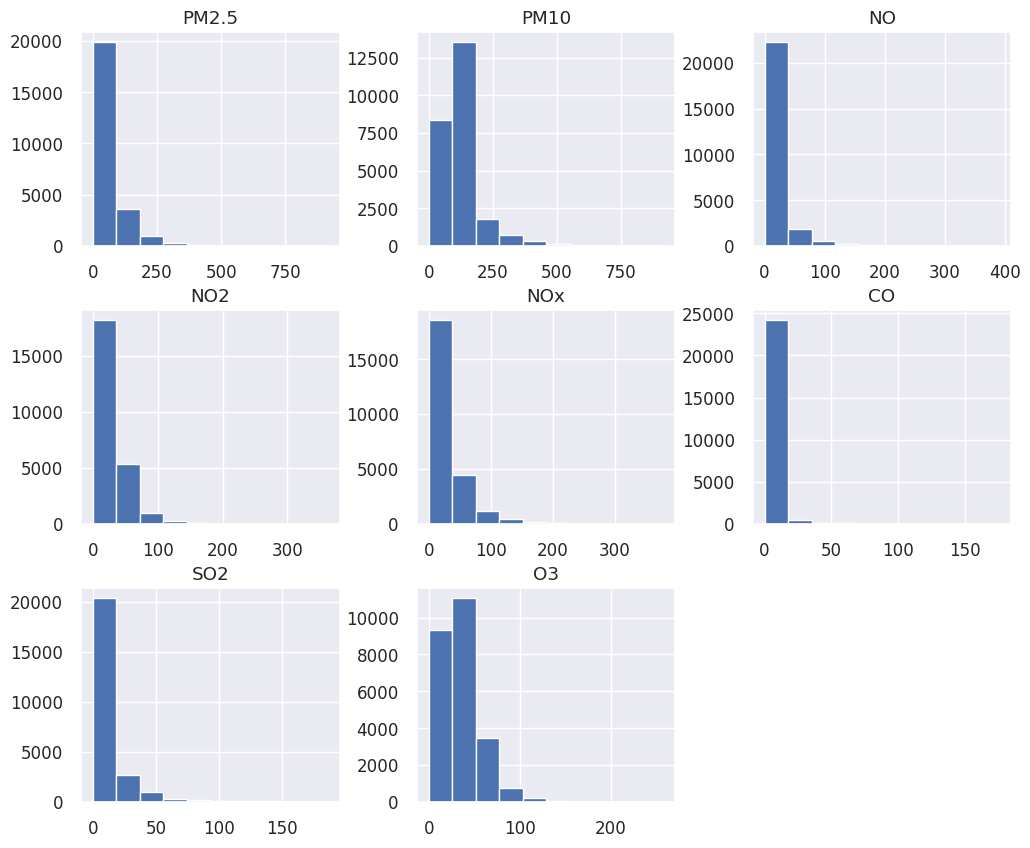

In [22]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','CO','SO2','O3']

df[pollutants].hist(figsize=(12,10))

plt.show()

In [5]:
'''MODULE 1 — Monthly AQI Aggregation'''

'''Monthly AQI Mean'''
monthly_aqi = df.groupby('Month')['AQI'].mean()

monthly_aqi

,AQI
Month,
1,231.674918
2,202.905197
3,164.735281
4,143.355120
5,135.489579
6,120.198379
7,111.854575
8,113.613176
9,115.191804


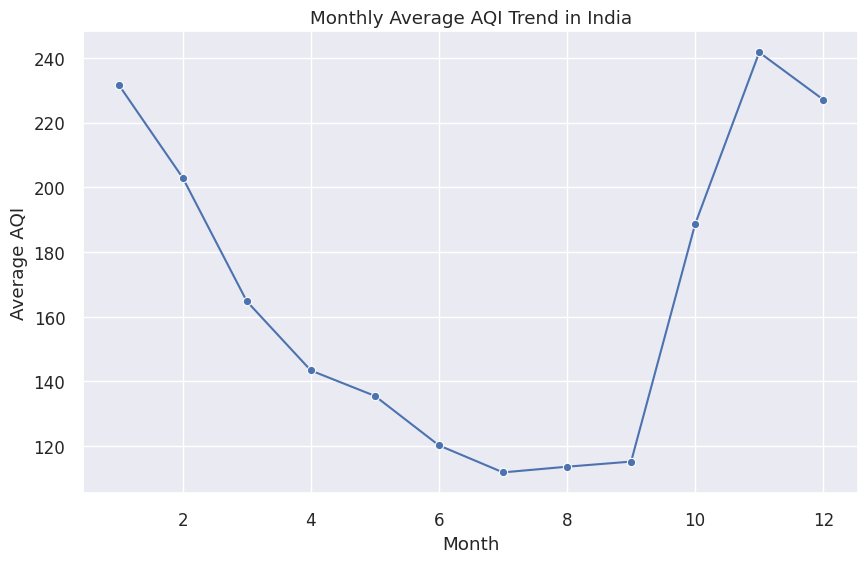

In [6]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_aqi.index,
    y=monthly_aqi.values,
    marker='o'
)

plt.title("Monthly Average AQI Trend in India")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.grid(True)

plt.show()

Interpretation

Possible observations:

Winter months show higher AQI
Monsoon months show reduced AQI
Seasonal atmospheric changes affect pollution dispersion

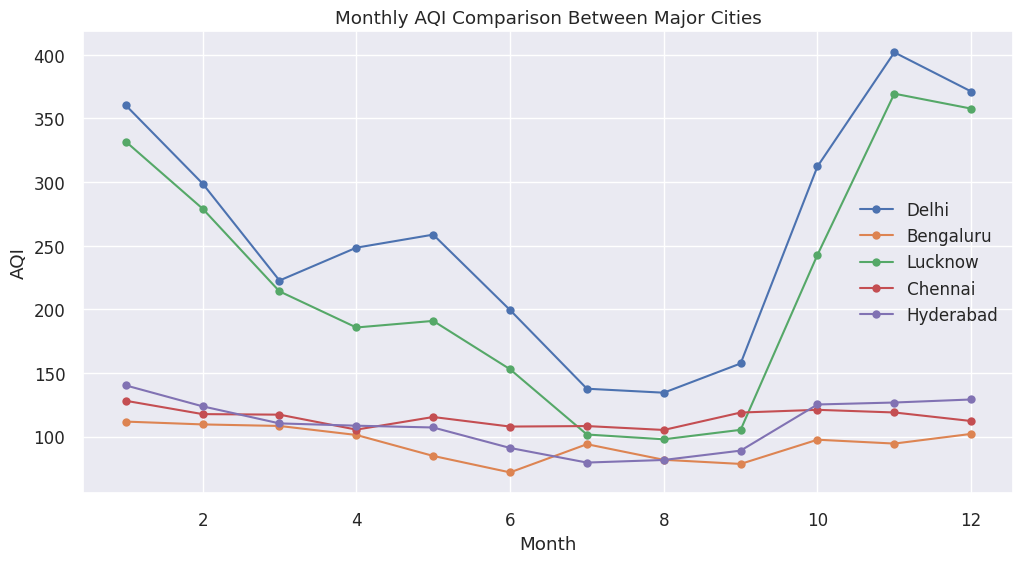

In [7]:
'''Monthly AQI Across Cities'''
monthly_city = df.groupby(['City','Month'])['AQI'].mean().reset_index()

plt.figure(figsize=(12,6))

top_cities = df['City'].value_counts().head(5).index

for city in top_cities:

    city_data = monthly_city[monthly_city['City']==city]

    plt.plot(
        city_data['Month'],
        city_data['AQI'],
        marker='o',
        label=city
    )

plt.title("Monthly AQI Comparison Between Major Cities")
plt.xlabel("Month")
plt.ylabel("AQI")

plt.legend()

plt.grid(True)

plt.show()

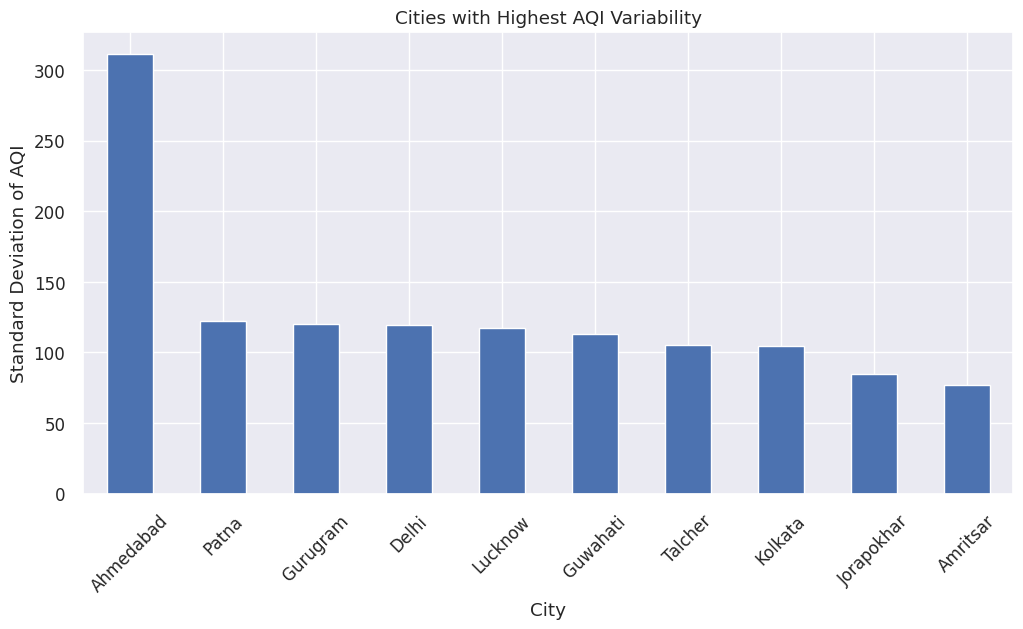

In [8]:
'''MODULE 2 — Variability Study (Standard Deviation)'''

'''Calculate AQI Variability'''

city_variability = df.groupby('City')['AQI'].std().sort_values(ascending=False)

city_variability.head(10)

plt.figure(figsize=(12,6))

city_variability.head(10).plot(
    kind='bar'
)

plt.title("Cities with Highest AQI Variability")
plt.xlabel("City")
plt.ylabel("Standard Deviation of AQI")

plt.xticks(rotation=45)

plt.show()

Interpretation

High variability cities may indicate:

Industrial emission fluctuations
Weather influence
Construction activity
Traffic variation

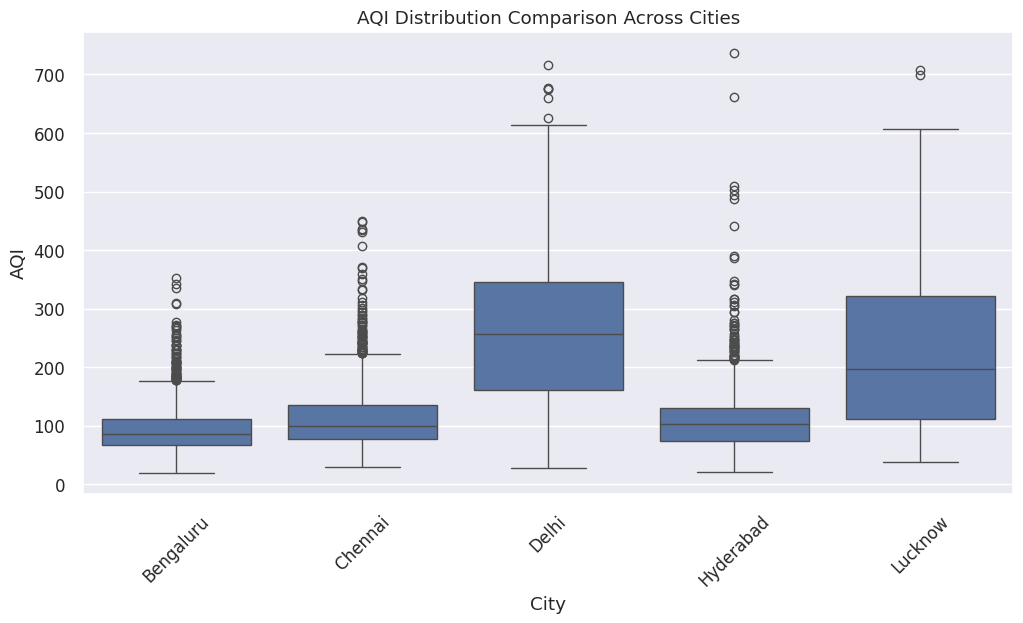

In [9]:
'''AQI Distribution Analysis'''
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[df['City'].isin(top_cities)],
    x='City',
    y='AQI'
)

plt.title("AQI Distribution Comparison Across Cities")

plt.xticks(rotation=45)

plt.show()

Boxplots show:

Median AQI
Pollution spread
Extreme pollution events

In [10]:
'''MODULE 3 — Hypothesis Testing Across Cities'''

'''ANOVA Test'''

top_cities = df['City'].value_counts().head(5).index

city_data = []

for city in top_cities:

    city_data.append(df[df['City']==city]['AQI'])

f_stat, p_value = stats.f_oneway(*city_data)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:

    print("Reject Null Hypothesis")
    print("AQI differs significantly between cities")

else:

    print("Fail to reject Null Hypothesis")
    print("No significant difference found")

F-statistic: 1519.3048759181715
P-value: 0.0
Reject Null Hypothesis
AQI differs significantly between cities


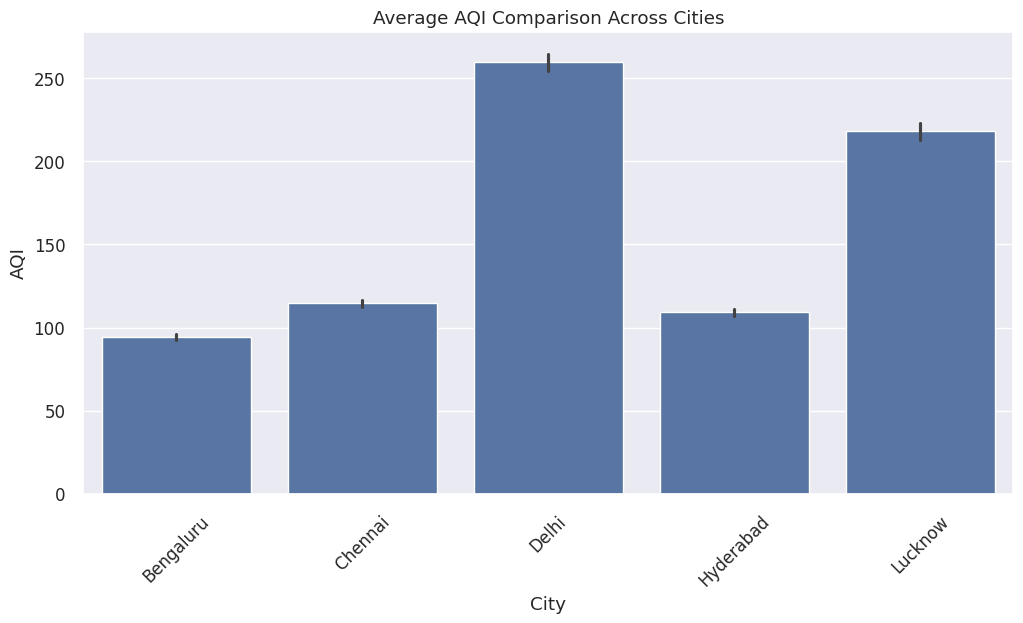

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df[df['City'].isin(top_cities)],
    x='City',
    y='AQI'
)

plt.title("Average AQI Comparison Across Cities")

plt.xticks(rotation=45)

plt.show()

In [12]:
'''MODULE 4 — Seasonal Trend Analysis'''
'''Define Seasons'''

def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8,9]:
        return "Monsoon"

    else:
        return "Post-Monsoon"

df['Season'] = df['Month'].apply(get_season)

In [13]:
'''Seasonal AQI Calculation'''
seasonal_aqi = df.groupby('Season')['AQI'].mean()

seasonal_aqi

,AQI
Season,
Monsoon,115.555426
Post-Monsoon,215.473464
Summer,147.670392
Winter,220.610764


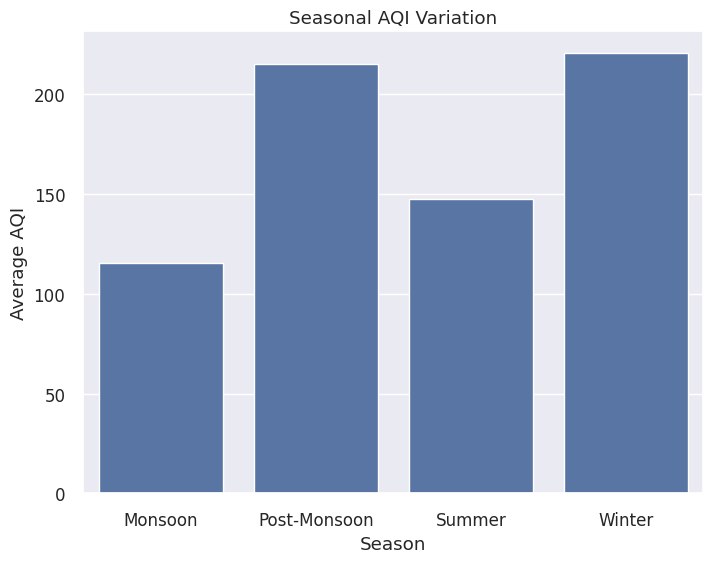

In [14]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=seasonal_aqi.index,
    y=seasonal_aqi.values
)

plt.title("Seasonal AQI Variation")

plt.xlabel("Season")
plt.ylabel("Average AQI")

plt.show()

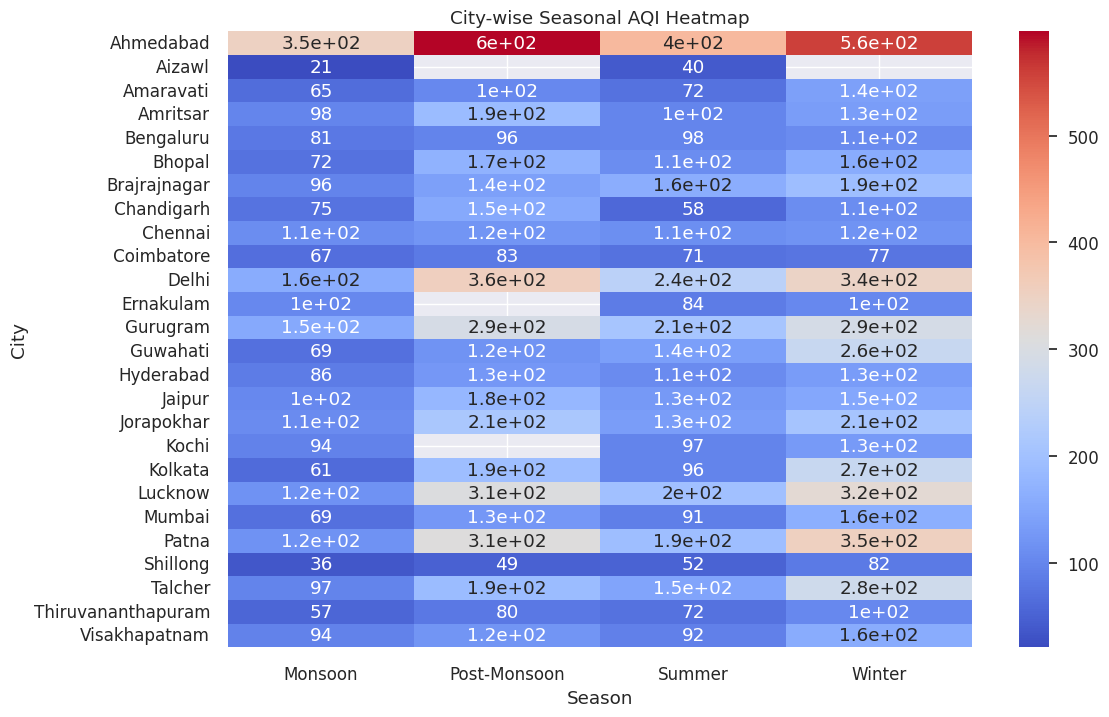

In [16]:
'''Seasonal AQI Heatmap'''
'''Ayush Singh'''
season_city = df.pivot_table(
    values='AQI',
    index='City',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    season_city,
    annot = True,
    cmap='coolwarm'
)

plt.title("City-wise Seasonal AQI Heatmap")

plt.show()

In [17]:
'''MODULE 5 — Environmental Interpretation'''
'''Pollutant Correlation Analysis'''

pollutants = [
    'PM2.5','PM10','NO','NO2','NOx',
    'CO','SO2','O3','AQI'
]

corr_matrix = df[pollutants].corr()

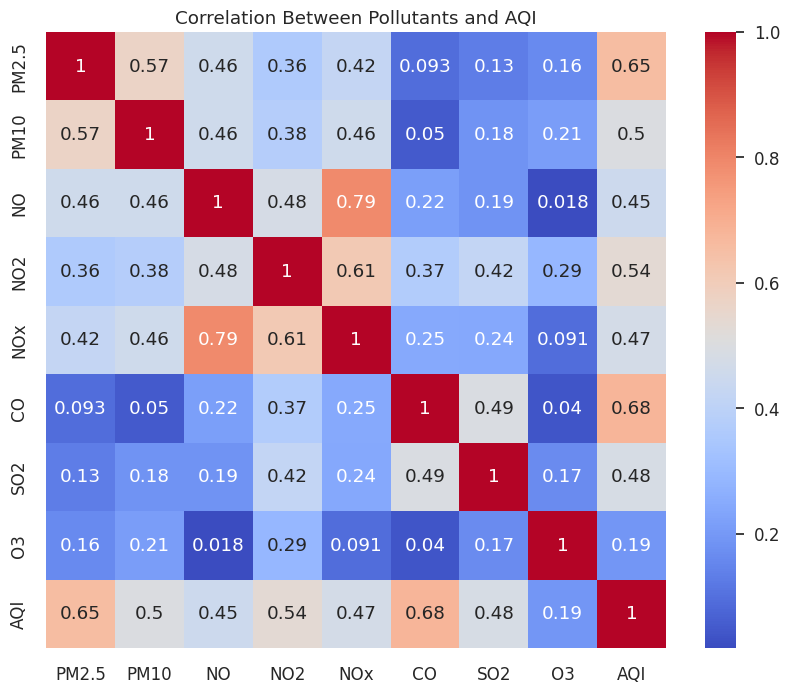

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Pollutants and AQI")

plt.show()

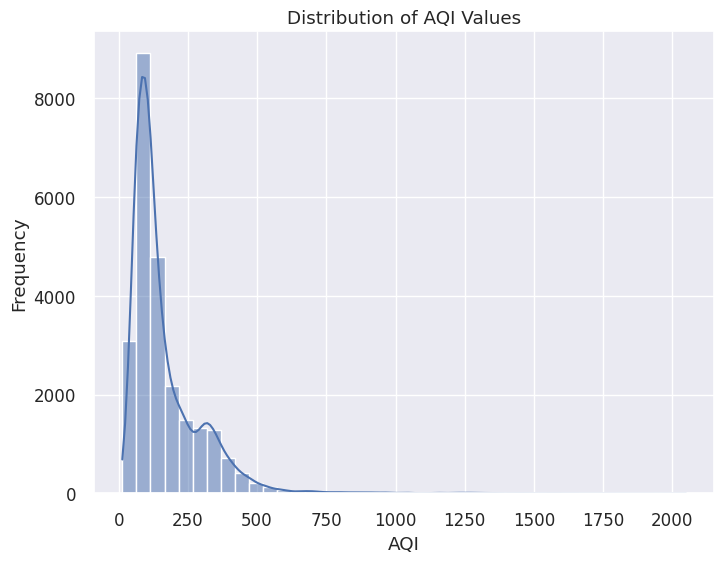

In [19]:
'''AQI Distribution'''
plt.figure(figsize=(8,6))

sns.histplot(
    df['AQI'],
    bins=40,
    kde=True
)

plt.title("Distribution of AQI Values")

plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

# Interpretation of Results

The analysis of AQI data across different cities revealed clear pollution patterns.

- Monthly aggregation showed that AQI varies throughout the year, with higher pollution during colder months.
- Variability analysis indicated that some cities experience greater fluctuations in pollution levels.
- Hypothesis testing confirmed that AQI levels differ significantly across cities.
- Seasonal analysis showed higher pollution during winter and lower pollution during the monsoon season.
- Correlation analysis highlighted that **PM2.5 and PM10 are the major contributors to AQI**.

These observations demonstrate that both environmental and urban factors influence air quality.

# Conclusion

This project analyzed air quality variability across cities using statistical and data science techniques.

The results show that AQI levels vary significantly across cities and seasons. Winter months tend to have the highest pollution levels, while monsoon seasons generally show improved air quality due to rainfall.

The analysis also indicates that particulate pollutants such as **PM2.5 and PM10 strongly influence AQI values**.

Overall, this study highlights the importance of continuous air quality monitoring and the role of data analysis in understanding environmental pollution patterns.